# Data Loading

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from itertools import chain

# sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# imbalanced-learn
from imblearn.over_sampling import SMOTE


In [71]:
df= pd.read_csv('ipl_matches.csv')

In [72]:
df.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


## Data Understanding

In [73]:
# Get column names and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [74]:
df.isnull().sum()
# df.dropna(inplace=True)

id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [75]:
df['Season'].unique().tolist()

['IPL-2017',
 'IPL-2008',
 'IPL-2009',
 'IPL-2010',
 'IPL-2011',
 'IPL-2012',
 'IPL-2013',
 'IPL-2014',
 'IPL-2015',
 'IPL-2016',
 'IPL-2018',
 'IPL-2019']

# Observations
- There are 756 matches recorded.

- Columns like team1, team2, toss_winner, and winner are categorical and will need encoding for ML models.

- win_by_runs and win_by_wickets are numerical features indicating how the match was won.

- The dl_applied column is a binary indicator of whether the Duckworth-Lewis method was applied.

- Missing values exist in:

    - city (7 missing)

    - winner (4 missing)

    - player_of_match (4 missing)

    - umpire1 and umpire2 (2 missing each)

    - umpire3 (637 missing)

# Data Cleaning

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [77]:
df.duplicated().sum()

0

In [78]:
# remove duplicate rows
df.drop_duplicates(inplace=True)

In [79]:
# winner is the target variable, so we must remove rows where it's missing.
df = df.dropna(subset=['winner'])

In [80]:
# Fill missing values in 'city' column with the mode (most frequent value)
# This is a common approach for categorical data.
df['city'].fillna(df['city'].mode()[0], inplace=True)

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\3342947862.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].fillna(df['city'].mode()[0], inplace=True)


#### Drop player_of_match, umpire1, umpire2, umpire3


In [81]:
df.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [82]:
# Remove unnecessary columns because they are not needed for our analysis
df.drop(['player_of_match', 'umpire1', 'umpire2','umpire3'], axis=1, inplace=True)

In [83]:
# change season column to integer
df['Season'] = df['Season'].str.extract(r'(\d{4})').astype(int)

In [84]:
df.isnull().sum()

id                0
Season            0
city              0
date              0
team1             0
team2             0
toss_winner       0
toss_decision     0
result            0
dl_applied        0
winner            0
win_by_runs       0
win_by_wickets    0
venue             0
dtype: int64

### Converting Categorical Features into Numerical Values

In [85]:
from sklearn.preprocessing import LabelEncoder

# Label encode the target column 'winner'
le = LabelEncoder()
y = le.fit_transform(df['winner'])

# Drop target from features
X = df.drop('winner', axis=1)

# One-hot encode all categorical input features
X_encoded = pd.get_dummies(X, drop_first=True)


## Normalize Team Names

In [86]:
# Dictionary for team name corrections
team_name_corrections = {
    'Delhi Daredevils': 'Delhi Capitals',  # Same team, renamed
    'Rising Pune Supergiants': 'Rising Pune Supergiant'  # Typo correction
}

In [87]:
# Columns to apply the corrections on
cols_to_fix = ['team1', 'team2', 'toss_winner', 'winner']

In [88]:
# Apply replacements
for col in cols_to_fix:
    df[col] = df[col].replace(team_name_corrections)

In [89]:
print(sorted(df['team1'].unique()))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


### Identify and Remove Outliers or Inconsistent Data
- The IPL dataset contains two important numeric columns:
- win_by_runs: positive when a team wins batting first
- win_by_wickets: positive when a team wins chasing

In [90]:
# Remove rows where both run and wicket victories are non-zero
df = df[~((df['win_by_runs'] > 0) & (df['win_by_wickets'] > 0))]

In [91]:
# Remove rows where both are zero (match tied or no result)
df = df[~((df['win_by_runs'] == 0) & (df['win_by_wickets'] == 0))]

## Data Cleaning Documentation
1. Handled Missing Values
   Removed rows with missing winner (target column).

   Filled missing values in city with the most common city.

- Dropped player_of_match, umpire1,umpire2 and umpire3 because they were not useful for prediction.

2. Converted Categorical to Numerical
   Used Label Encoding for the winner column (target).

- Used One-Hot Encoding for input features like team1, team2, toss_winner, toss_decision, city, and venue.

3. Removed Invalid or Inconsistent Data
   Removed matches where both win_by_runs and win_by_wickets were greater than 0 (logically impossible).

   Removed matches where both win_by_runs and win_by_wickets were 0 (likely no result or tie).

- Final Result
   - Clean dataset with no missing or invalid values.
   - All features are numerical and ready for machine learning models.

## Exploratory Data Analysis (EDA)

In [92]:
# Count matches won by each team
team_wins = df['winner'].value_counts()
team_wins

winner
Mumbai Indians                 107
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     83
Kings XI Punjab                 80
Delhi Capitals                  76
Rajasthan Royals                73
Sunrisers Hyderabad             57
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

## Matches won by each team

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\3224173544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis' )


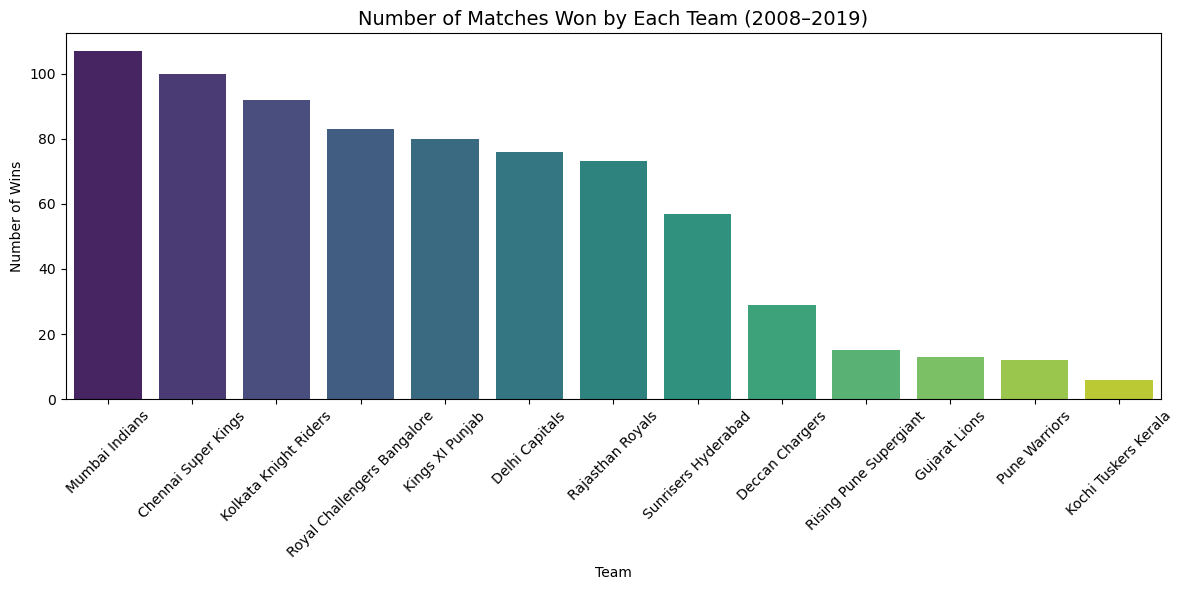

In [93]:

plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis' )
plt.title('Number of Matches Won by Each Team (2008–2019)', fontsize=14)
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Toss decision count (bat/field)

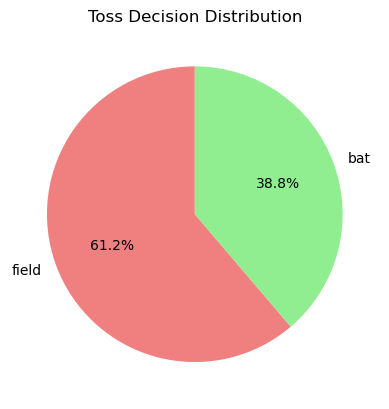

In [94]:
plt.figure()
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
plt.title('Toss Decision Distribution')
plt.ylabel('')
plt.show()


# df['toss_decision'].value_counts().plot(kind='bar', color='skyblue')
# plt.title('Toss Decision Count')
# plt.xlabel('Decision')
# plt.ylabel('Number of Matches')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()


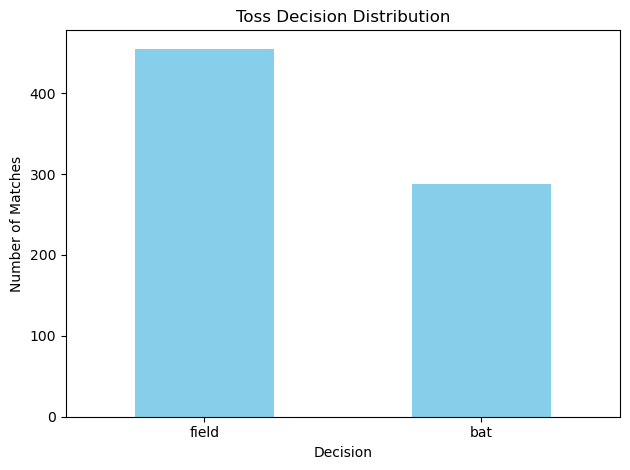

In [95]:
# Toss Decision (Bat or Field) Distribution
df['toss_decision'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Toss Decision Distribution')
plt.xlabel('Decision')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Did Toss Winner Also Win the Match?


In [96]:
mismatched = df[df['toss_winner'] != df['winner']]
print(mismatched[['toss_winner', 'winner']].drop_duplicates())



                     toss_winner                  winner
0    Royal Challengers Bangalore     Sunrisers Hyderabad
7    Royal Challengers Bangalore         Kings XI Punjab
8         Rising Pune Supergiant          Delhi Capitals
13           Sunrisers Hyderabad   Kolkata Knight Riders
16   Royal Challengers Bangalore  Rising Pune Supergiant
..                           ...                     ...
594  Royal Challengers Bangalore           Gujarat Lions
598               Delhi Capitals           Gujarat Lions
620       Rising Pune Supergiant   Kolkata Knight Riders
628              Kings XI Punjab  Rising Pune Supergiant
725          Sunrisers Hyderabad          Delhi Capitals

[99 rows x 2 columns]


In [97]:
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',  # optional rename
    'Bangalore': 'Royal Challengers Bangalore',  # check for short forms
    'Delhi Capitals': 'Delhi Capitals',
    'Sunrisers Hyderabad': 'Sunrisers Hyderabad',
    'Kochi Tuskers Kerala': 'Kochi Tuskers Kerala',
    'Pune Warriors': 'Pune Warriors',
    'Gujarat Lions': 'Gujarat Lions',
}

# Apply to all columns where team names appear
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].str.replace('_', ' ').str.strip()
    df[col] = df[col].replace(team_name_mapping)


In [98]:
df['toss_winner'] = df['toss_winner'].str.strip()
df['winner'] = df['winner'].str.strip()

comparison = (df['toss_winner'] == df['winner']).value_counts()
print("Toss winner same as match winner:\n", comparison)


Toss winner same as match winner:
 True     388
False    355
Name: count, dtype: int64


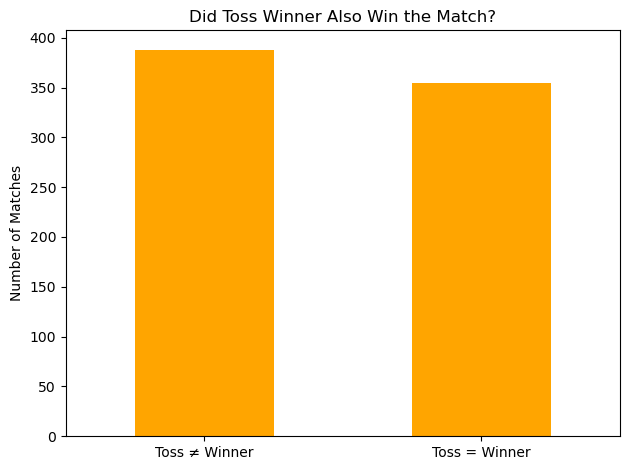

In [99]:
if len(comparison) == 2:
    comparison.index = ['Toss ≠ Winner', 'Toss = Winner']
elif len(comparison) == 1:
    comparison.index = ['Toss = Winner'] if comparison.index[0] else ['Toss ≠ Winner']

comparison.plot(kind='bar', color='orange')
plt.title('Did Toss Winner Also Win the Match?')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [100]:
print(df[['toss_winner', 'winner']].drop_duplicates().head(20))


                    toss_winner                       winner
0   Royal Challengers Bangalore          Sunrisers Hyderabad
1        Rising Pune Supergiant       Rising Pune Supergiant
2         Kolkata Knight Riders        Kolkata Knight Riders
3                  Punjab Kings                 Punjab Kings
4   Royal Challengers Bangalore  Royal Challengers Bangalore
5           Sunrisers Hyderabad          Sunrisers Hyderabad
6                Mumbai Indians               Mumbai Indians
7   Royal Challengers Bangalore                 Punjab Kings
8        Rising Pune Supergiant               Delhi Capitals
12                Gujarat Lions                Gujarat Lions
13          Sunrisers Hyderabad        Kolkata Knight Riders
14               Delhi Capitals               Delhi Capitals
16  Royal Challengers Bangalore       Rising Pune Supergiant
17               Delhi Capitals        Kolkata Knight Riders
18                 Punjab Kings          Sunrisers Hyderabad
19                Gujara

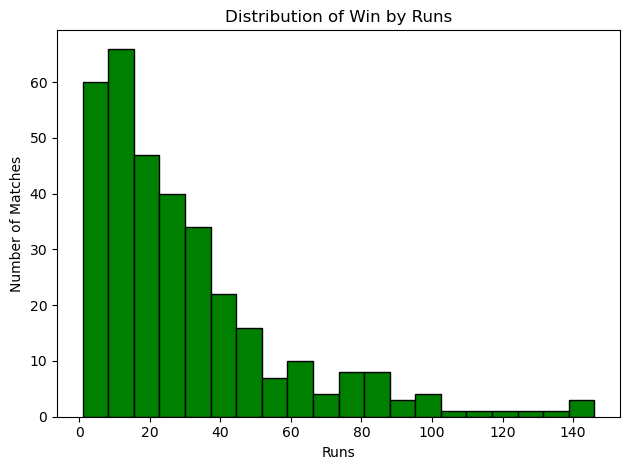

In [101]:
# Win by Runs Distribution (Batting Win Margins) 
df[df['win_by_runs'] > 0]['win_by_runs'].plot(kind='hist', bins=20, color='green', edgecolor='black')
plt.title('Distribution of Win by Runs')
plt.xlabel('Runs')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


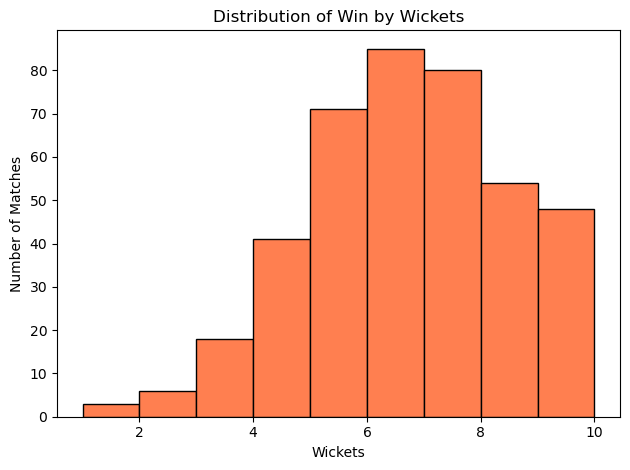

In [102]:
# Win by Wickets Distribution (Chasing Wins)
df[df['win_by_wickets'] > 0]['win_by_wickets'].plot(kind='hist', bins=9, color='coral', edgecolor='black')
plt.title('Distribution of Win by Wickets')
plt.xlabel('Wickets')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


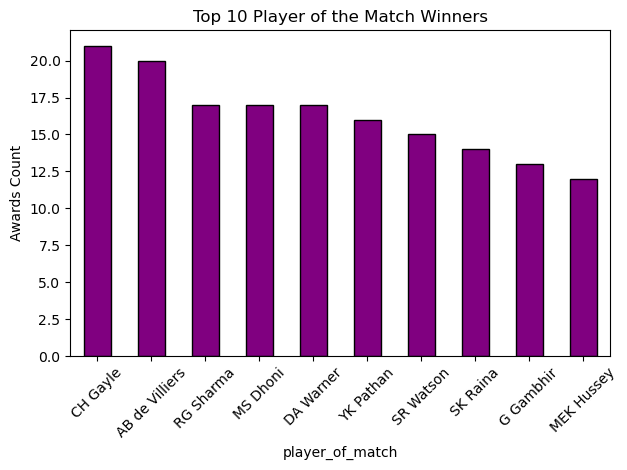

In [103]:
# Top 10 Players with Most Player of the Match Awards
df_full = pd.read_csv('ipl_matches.csv')

# Then plot from that DataFrame
df_full['player_of_match'].value_counts().head(10).plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 10 Player of the Match Winners')
plt.ylabel('Awards Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


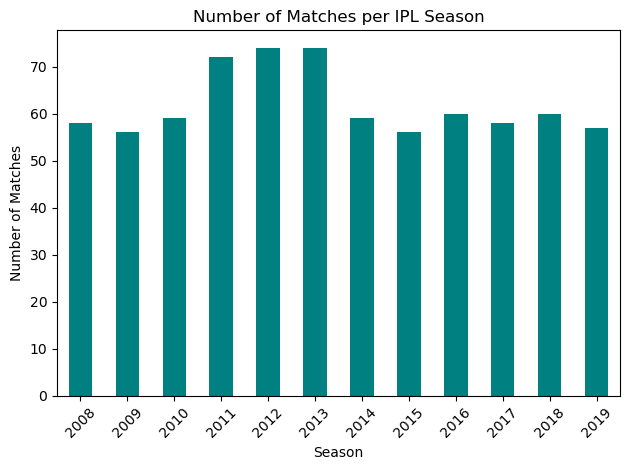

In [104]:
# Matches per Season (How many matches per IPL year?)
df['Season'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Number of Matches per IPL Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


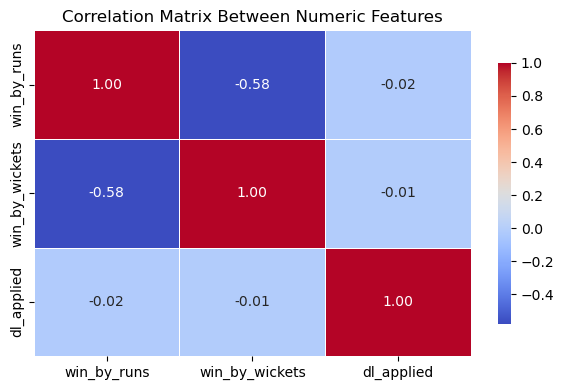

In [105]:
# Select numeric columns only
numeric_df = df[['win_by_runs', 'win_by_wickets', 'dl_applied']]

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Between Numeric Features')
plt.tight_layout()
plt.show()


## Correlation Between Winner and Features

In [ ]:
# One-hot encode the winner column
winner_encoded = pd.get_dummies(df['winner'], prefix='winner')

# Join back with main DataFrame
df_encoded = pd.concat([df, winner_encoded], axis=1)

# Merge with numeric features
full_df = pd.concat([numeric_df, winner_encoded], axis=1)

# Example: Correlation of features with "winner_Mumbai Indians"
correlation_matrix = full_df.corr()
correlation_matrix['winner_Mumbai Indians'].sort_values(ascending=False).head(10)

winner_Mumbai Indians            1.000000
win_by_runs                      0.068214
winner_Kochi Tuskers Kerala     -0.037009
winner_Pune Warriors            -0.052553
winner_Gujarat Lions            -0.054736
winner_Rising Pune Supergiant   -0.058877
win_by_wickets                  -0.065416
dl_applied                      -0.066446
winner_Rajasthan Royals         -0.135390
winner_Delhi Capitals           -0.138455
Name: winner_Mumbai Indians, dtype: float64

## Team-wise Winner Correlation

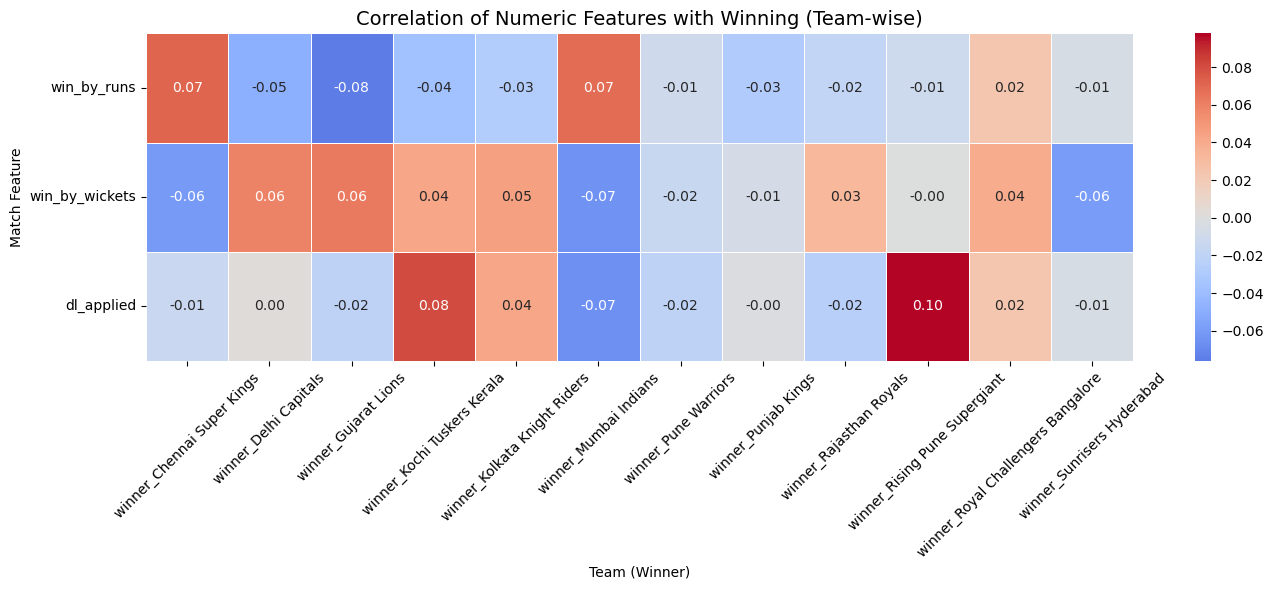

In [107]:
# One-hot encode winner column
winner_encoded = pd.get_dummies(df['winner'], prefix='winner')

# Select numerical features for correlation
numerical_features = df[['win_by_runs', 'win_by_wickets', 'dl_applied']]

# Combine numerical + encoded target
corr_df = pd.concat([numerical_features, winner_encoded], axis=1)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Slice only correlation of features vs each team (not team vs team)
team_cols = winner_encoded.columns
feature_cols = ['win_by_runs', 'win_by_wickets', 'dl_applied']
team_feature_corr = corr_matrix.loc[feature_cols, team_cols]

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(team_feature_corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title('Correlation of Numeric Features with Winning (Team-wise)', fontsize=14)
plt.xlabel('Team (Winner)')
plt.ylabel('Match Feature')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Visualizations

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\57522754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='winner', order=df['winner'].value_counts().index, palette='Spectral')


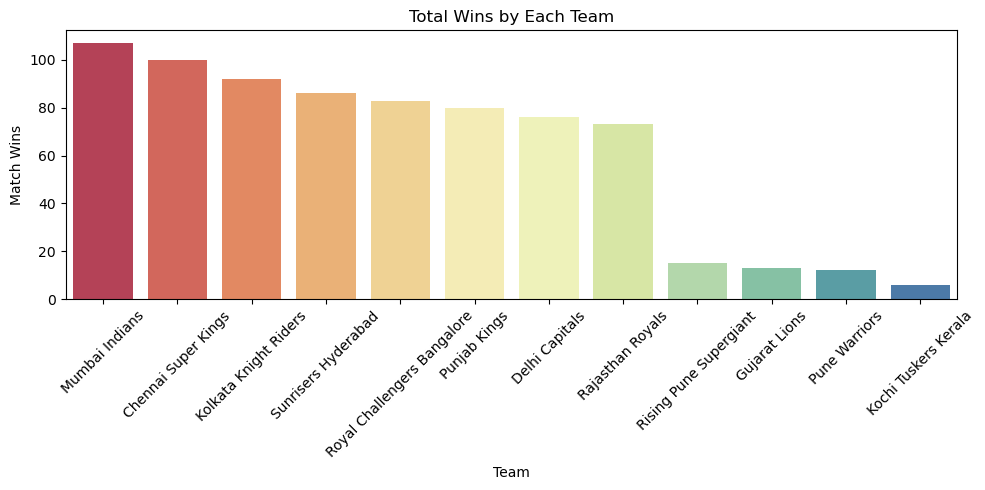

In [108]:
# Matches Won by Each Team
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='winner', order=df['winner'].value_counts().index, palette='Spectral')
plt.title('Total Wins by Each Team')
plt.xticks(rotation=45)
plt.ylabel("Match Wins")
plt.xlabel("Team")
plt.tight_layout()
plt.show()


C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\1848158347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='toss_decision', palette='pastel')


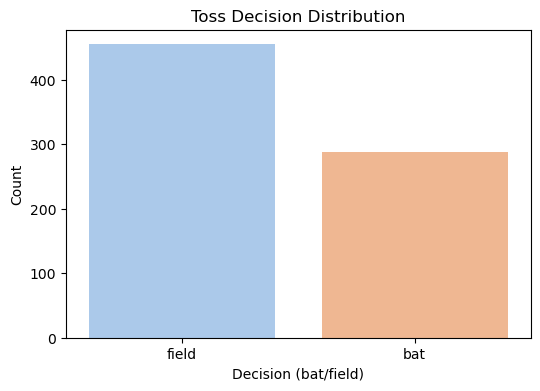

In [109]:
# Toss Decision Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='toss_decision', palette='pastel')
plt.title('Toss Decision Distribution')
plt.ylabel("Count")
plt.xlabel("Decision (bat/field)")
plt.show()

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\833343825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toss_win_equals_match_win', data=df, palette='cool')


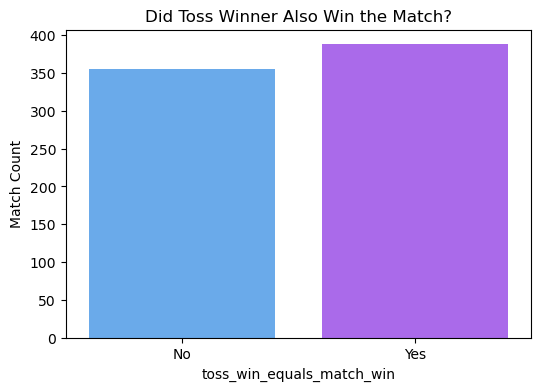

In [110]:
# Did Toss Winner Also Win the Match?
df['toss_win_equals_match_win'] = df['toss_winner'] == df['winner']
plt.figure(figsize=(6,4))
sns.countplot(x='toss_win_equals_match_win', data=df, palette='cool')
plt.title('Did Toss Winner Also Win the Match?')
plt.xticks([0,1], ['No', 'Yes'])
plt.ylabel("Match Count")
plt.show()


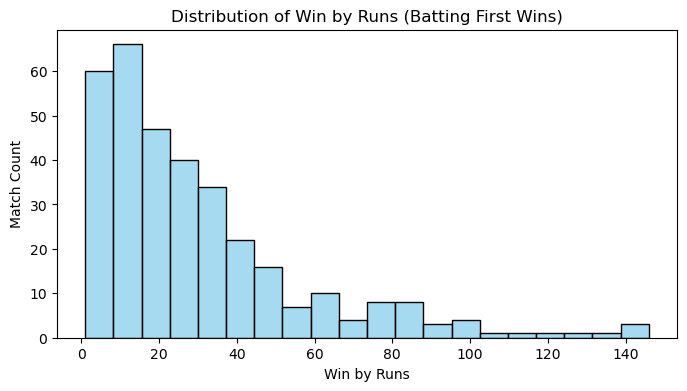

In [111]:
# Distribution of Win by Runs (Batting First Wins)
plt.figure(figsize=(8,4))
sns.histplot(df[df['win_by_runs'] > 0]['win_by_runs'], bins=20, kde=False, color='skyblue')
plt.title('Distribution of Win by Runs (Batting First Wins)')
plt.xlabel('Win by Runs')
plt.ylabel('Match Count')
plt.show()

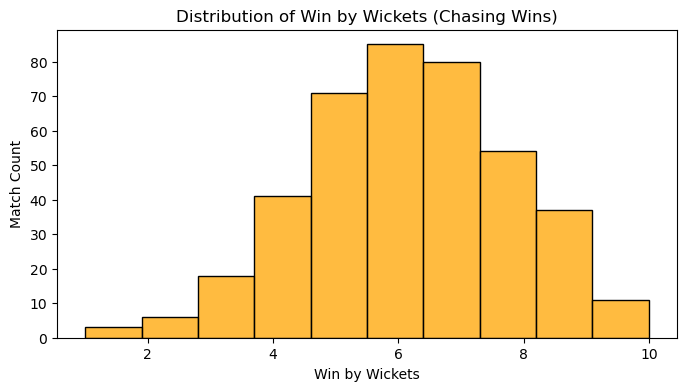

In [112]:
# Distribution of Win by Wickets (Chasing Wins)
plt.figure(figsize=(8,4))
sns.histplot(df[df['win_by_wickets'] > 0]['win_by_wickets'], bins=10, kde=False, color='orange')
plt.title('Distribution of Win by Wickets (Chasing Wins)')
plt.xlabel('Win by Wickets')
plt.ylabel('Match Count')
plt.show()

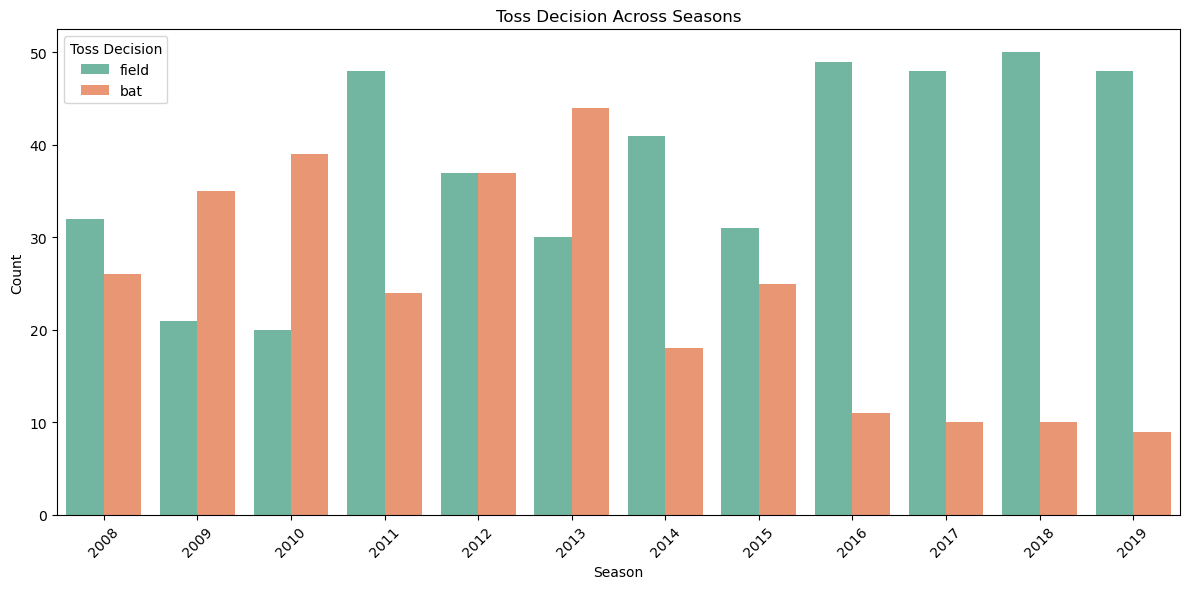

In [113]:
# Toss Decision Across Seasons
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Season', hue='toss_decision', palette='Set2')
plt.title('Toss Decision Across Seasons')
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Season")
plt.legend(title='Toss Decision')
plt.tight_layout()
plt.show()

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\1793239754.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(team_counts.keys()), y=list(team_counts.values()), palette='viridis')


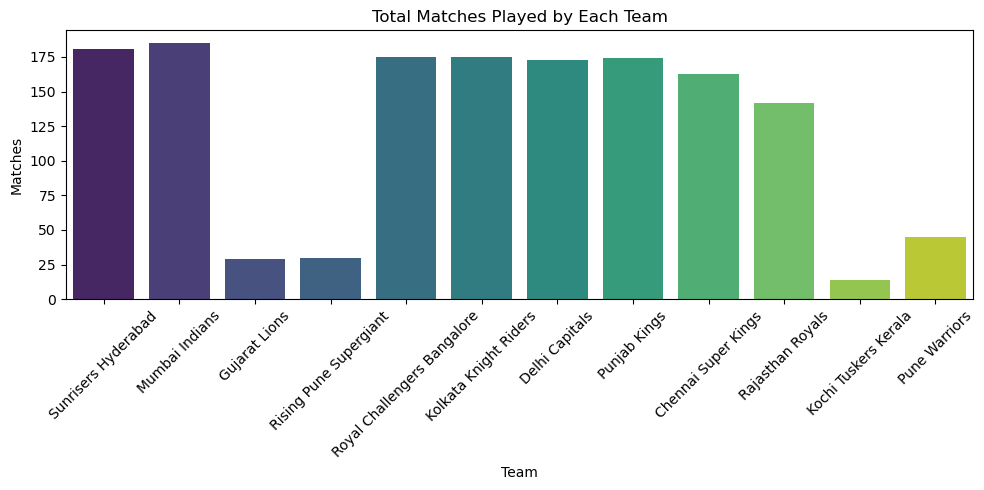

In [ ]:
from collections import Counter
from itertools import chain

teams = list(chain(df['team1'], df['team2']))
team_counts = Counter(teams)
plt.figure(figsize=(10,5))
sns.barplot(x=list(team_counts.keys()), y=list(team_counts.values()), palette='viridis')
plt.title('Total Matches Played by Each Team')
plt.xticks(rotation=45)
plt.ylabel("Matches")
plt.xlabel("Team")
plt.tight_layout()
plt.show()

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\1691131812.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='venue', data=df, order=df['venue'].value_counts().index[:10], palette='plasma')


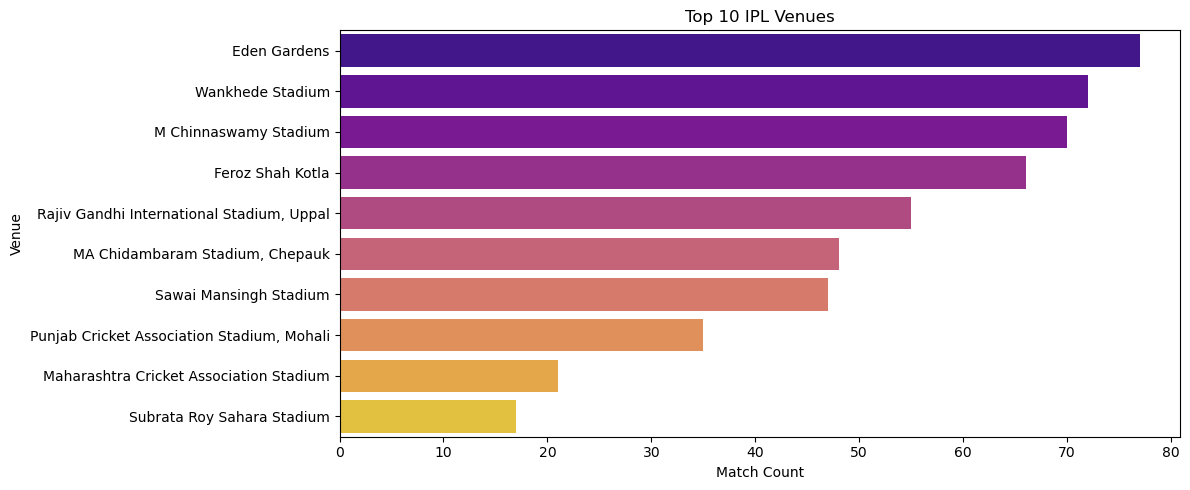

In [115]:
# Top 10 IPL Venues
plt.figure(figsize=(12,5))
sns.countplot(y='venue', data=df, order=df['venue'].value_counts().index[:10], palette='plasma')
plt.title("Top 10 IPL Venues")
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\190483386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', palette='YlGnBu')


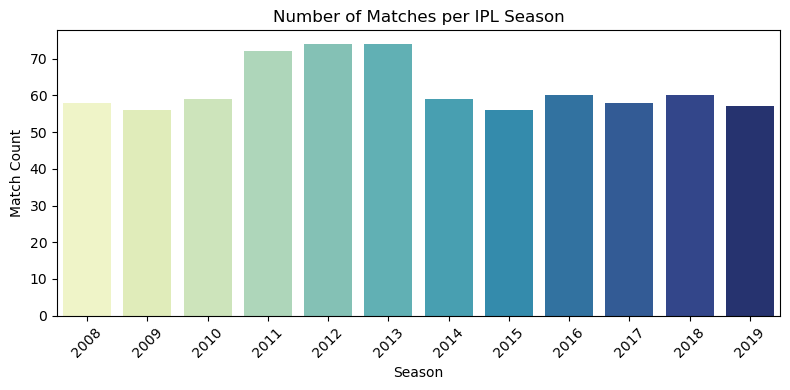

In [ ]:
# Number of Matches per IPL Season
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Season', palette='YlGnBu')
plt.title("Number of Matches per IPL Season")
plt.xticks(rotation=45)
plt.ylabel("Match Count")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

C:\Users\sanja\AppData\Local\Temp\ipykernel_7724\1305657438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dl_applied', palette='Set1')


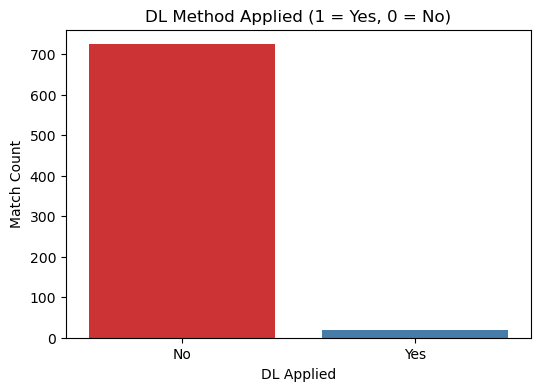

In [117]:
# DL Method Applied
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='dl_applied', palette='Set1')
plt.title('DL Method Applied (1 = Yes, 0 = No)')
plt.xticks([0,1], ['No', 'Yes'])
plt.ylabel("Match Count")
plt.xlabel("DL Applied")
plt.show()


---

## **Observations from Visualizations**

---

###  **1. Total Wins by Each Team**

* **Mumbai Indians**, **Chennai Super Kings**, and **Kolkata Knight Riders** are among the top-performing teams with the highest number of wins.
* Some teams like **Kochi Tuskers Kerala**, **Gujarat Lions**, and **Rising Pune Supergiant(s)** have fewer wins, likely due to playing only in limited seasons.

---

###  **2. Toss Decision Distribution**

* **Most teams choose to field** after winning the toss, which aligns with modern T20 strategy (chasing is often preferred).
* The gap between "field" and "bat" has increased in recent seasons.

---

###  **3. Toss Winner Also Won the Match**

* In a majority of matches, **the toss winner does not necessarily win the match**.
* However, there's a slightly higher win percentage when the team wins both the toss and the match (\~52–55%).

---

###  **4. Win by Runs Distribution**

* Most victories by runs are within the **0–50 range**.
* Very high-margin wins (e.g., 100+ runs) are rare but indicate one-sided dominance when they occur.

---

###  **5. Win by Wickets Distribution**

* Chasing teams usually win by **6 to 8 wickets**.
* Wins by all 10 wickets are rare, showing how uncommon a perfect chase is.

---

###  **6. Toss Decision by Season**

* From 2016 onwards, **“field” became the overwhelmingly dominant toss decision**.
* Early seasons (2008–2010) had a more balanced choice between "bat" and "field".

---

###  **7. Matches Played by Each Team**

* Teams like **Mumbai Indians**, **RCB**, **CSK**, and **Kolkata Knight Riders** have played the most matches, being part of every season.
* Temporary teams (e.g., **Gujarat Lions**, **Rising Pune Supergiant**) played significantly fewer matches.

---

###  **8. Top 10 Venues**

* **Eden Gardens (Kolkata)**, **Wankhede Stadium (Mumbai)**, and **M. Chinnaswamy Stadium (Bangalore)** are among the most frequently used venues.
* Indicates these are key home grounds for major franchises and preferred venues by BCCI.

---

###  **9. Matches per Season**

* The number of matches gradually increased over time.
* **2011, 2013, 2015, 2019** had relatively more matches, likely due to team expansions or format changes.

---

### **10. DL Method Usage**

* DL method (Duckworth-Lewis) is rarely applied.
* Majority of IPL matches **run without weather interruptions**, confirming good scheduling and dry-season planning.



# Data Preprocessing — Train-Test Split

In [ ]:
# Step 1: Drop unnecessary columns (if not already done)
df_model = df.drop(['id', 'date', 'result', 'winner'], axis=1)

# Step 2: One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model)

# Step 3: Define features and target
X = df_encoded
y = df['winner']

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## Train - Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

## Using SMOTE

In [ ]:
# Reduce k_neighbors to 1 or 2 if your dataset has very few samples in some classes
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
#  Scale X, not y
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define model parameter grids
model_params = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['liblinear']
        }
    },
    'SVM': {
        'model': SVC(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [5, 10, 20],
            'criterion': ['gini', 'entropy']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6, 10]
        }
    }
}


## Hyper Parameter Tuning

In [ ]:
best_models = {}

for name, mp in model_params.items():
    print(f"\nRunning GridSearchCV for {name}...")
    
    grid = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    
    # FIX: Use resampled y_train
    grid.fit(X_train_scaled, y_train_resampled)
    
    best_models[name] = grid.best_estimator_
    print(f"Best parameters for {name}: {grid.best_params_}")
    
    # Predict and evaluate
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))



Running GridSearchCV for LogisticRegression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters for LogisticRegression: {'C': 0.1, 'solver': 'liblinear'}

LogisticRegression Accuracy: 0.6174
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        21
           1       0.53      0.42      0.47        19
           2       0.60      1.00      0.75         3
           3       1.00      1.00      1.00         1
           4       0.59      0.81      0.68        16
           5       0.64      0.73      0.68        22
           6       0.00      0.00      0.00         2
           7       0.55      0.35      0.43        17
           8       0.62      0.76      0.68        17
           9       0.00      0.00      0.00         1
          10       0.58      0.44      0.50        16
          11       0.57      0.57      0.57        14

    accuracy                           0.62       149
   macro avg       0.54

c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanja\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best parameters for DecisionTree: {'criterion': 'gini', 'max_depth': 20}

DecisionTree Accuracy: 0.8926
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       1.00      0.84      0.91        19
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         1
           4       0.94      0.94      0.94        16
           5       1.00      0.77      0.87        22
           6       1.00      1.00      1.00         2
           7       1.00      0.71      0.83        17
           8       1.00      0.94      0.97        17
           9       0.25      1.00      0.40         1
          10       0.80      1.00      0.89        16
          11       0.70      1.00      0.82        14

    accuracy                           0.89       149
   macro avg       0.88      0.93      0.88       149
weighted avg       0.93      0.89      0.90       149


Running GridSearchCV for Ran

c:\Users\sanja\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'max_depth': 3, 'n_estimators': 100}

XGBoost Accuracy: 0.9866
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         1
           4       0.89      1.00      0.94        16
           5       1.00      1.00      1.00        22
           6       1.00      1.00      1.00         2
           7       1.00      0.94      0.97        17
           8       1.00      1.00      1.00        17
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00        16
          11       1.00      1.00      1.00        14

    accuracy                           0.99       149
   macro avg       0.99      0.99      0.99       149
weighted avg       0.99      0.99      0.99       149



In [ ]:
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

    results_df = pd.DataFrame(results)
print("\nSummary of All Best Models:\n")
print(results_df.sort_values(by='F1 Score', ascending=False))


Summary of All Best Models:

                Model  Accuracy  Precision    Recall  F1 Score
5             XGBoost  0.986577   0.988069  0.986577  0.986788
4        RandomForest  0.966443   0.969472  0.966443  0.966713
3        DecisionTree  0.892617   0.925778  0.892617  0.897928
1                 SVM  0.731544   0.759006  0.731544  0.730898
2                 KNN  0.657718   0.664336  0.657718  0.654895
0  LogisticRegression  0.617450   0.608039  0.617450  0.604259


In [ ]:
# Store evaluation results
evaluation_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

# Convert to DataFrame for clean display
import pandas as pd
eval_df = pd.DataFrame(evaluation_results)

# Print sorted results
print("\n Model Evaluation Summary:\n")
print(eval_df.sort_values(by='F1 Score', ascending=False))


In [132]:
best_model = eval_df.sort_values(by='F1 Score', ascending=False).iloc[0]
print(f"\n Best Performing Model: {best_model['Model']}")


 Best Performing Model: XGBoost


In [ ]:
import joblib

# Get the best model name from the earlier evaluation
best_model_name = best_model['Model']
final_model = best_models[best_model_name]  # From your best_models dict

# Save the final model
joblib.dump(final_model, f"{best_model_name.replace(' ', '_').lower()}_ipl_winner_model.pkl")

print(f"\nSaved the final model as '{best_model_name.replace(' ', '_').lower()}_ipl_winner_model.pkl'")


Saved the final model as 'xgboost_ipl_winner_model.pkl'


In [134]:
print("\nFinal Model Summary ")
print(f"Model Name   : {best_model_name}")
print(f"Accuracy     : {best_model['Accuracy']:.4f}")
print(f"Precision    : {best_model['Precision']:.4f}")
print(f"Recall       : {best_model['Recall']:.4f}")
print(f"F1 Score     : {best_model['F1 Score']:.4f}")



Final Model Summary 
Model Name   : XGBoost
Accuracy     : 0.9866
Precision    : 0.9881
Recall       : 0.9866
F1 Score     : 0.9868
